# Diabetic Retinopathy Severity Classification (APTOS 2019) — Advanced

This notebook **builds directly on the basic baseline**. There we trained two ResNets sequentially on one GPU and found clear weaknesses:

1. The second T4 GPU sat idle.
2. The two models were similar and never combined.
3. Class imbalance was ignored.
4. We had no idea *what* the models looked at.

Here we fix all of them, step by step:

- **Step A — Use both T4 GPUs.** Train **two models simultaneously**, one on `cuda:0` and one on `cuda:1`, via threads. With 4 models that's two parallel waves instead of four sequential runs.
- **Step B — Train 4 diverse models.** ResNet50, EfficientNet-B0, DenseNet121, ResNet18 — diversity for a stronger **ensemble**.
- **Step C — Handle imbalance.** Class-weighted loss + `WeightedRandomSampler` + stronger augmentation + cosine LR.
- **Step D — Ensemble.** Average softmax probabilities and compare against each single model.
- **Step E — Grad-CAM.** Overlay class-activation heatmaps to confirm the models attend to lesions.

The dataset here is provided as **one folder per class** (no `train.csv`). We scan those folders to build the label table, then keep the **same balanced held-out test set** recipe as before.

> **Hardware:** written for Kaggle's **2× NVIDIA T4** option. Set Accelerator = *GPU T4 x2* in the settings panel.

## 1. Imports & GPU check

In [1]:
import os, time, copy, threading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

torch.manual_seed(42); np.random.seed(42)

N_GPU = torch.cuda.device_count()
print("CUDA available:", torch.cuda.is_available(), "| GPUs:", N_GPU)
for i in range(N_GPU):
    print(f"  cuda:{i} -> {torch.cuda.get_device_name(i)}")
if N_GPU < 2:
    print("\nWARNING: <2 GPUs. Parallel training falls back to one device. "
          "On Kaggle set Accelerator = 'GPU T4 x2'.")

CUDA available: True | GPUs: 2
  cuda:0 -> Tesla T4
  cuda:1 -> Tesla T4


## 2. Scan the class folders & build paths (no train.csv)

There is **no `train.csv`** here. The dataset is organised as **one folder per class**:

```
/kaggle/input/datasets/shajinrp/diabetic-retinopathy/Dataset
├── No_DR/            <- class 0
├── Mild/             <- class 1
├── Moderate/         <- class 2
├── Severe/           <- class 3
└── Proliferative_DR/ <- class 4
```

So instead of reading a CSV, we **walk the 5 subfolders**, treat each folder name as the label, and collect every image path into the same `df` (columns `path` + `label`) that the rest of the notebook expects. Everything downstream is unchanged.

In [2]:
DATA_ROOT = Path("/kaggle/input/datasets/shajinrp/diabetic-retinopathy/Dataset")
if not DATA_ROOT.exists():
    # fallbacks in case the mount path differs slightly
    for alt in [
        Path("/kaggle/input/diabetic-retinopathy/Dataset"),
        Path("/kaggle/input/shajinrp/diabetic-retinopathy/Dataset"),
        Path("/kaggle/input/diabetic-retinopathy"),
    ]:
        if alt.exists():
            DATA_ROOT = alt
            break
print("Root:", DATA_ROOT, "| exists:", DATA_ROOT.exists())

# The 5 severity classes, ordered 0 -> 4. The folder names on disk are matched
# case-insensitively, with a few common aliases, so small naming differences still work.
CLASSES = ["No_DR", "Mild", "Moderate", "Severe", "Proliferative_DR"]
ALIASES = {
    "No_DR":            ["no_dr", "nodr", "no dr", "0", "healthy", "normal"],
    "Mild":             ["mild", "1"],
    "Moderate":         ["moderate", "2"],
    "Severe":           ["severe", "3"],
    "Proliferative_DR": ["proliferative_dr", "proliferativedr", "proliferate_dr",
                         "proliferative dr", "proliferative", "4", "pdr"],
}

# Map each actual subfolder on disk to a class index (0..4)
IMG_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
subdirs = [d for d in DATA_ROOT.iterdir() if d.is_dir()]
print("Found subfolders:", [d.name for d in subdirs])

def folder_to_label(folder_name):
    key = folder_name.strip().lower().replace("-", "_").replace(" ", "_")
    for idx, cls in enumerate(CLASSES):
        if key == cls.lower():
            return idx
        if key in [a.replace("-", "_").replace(" ", "_") for a in ALIASES[cls]]:
            return idx
    return None

rows = []
for d in subdirs:
    label = folder_to_label(d.name)
    if label is None:
        print(f"  (skipping unrecognised folder: {d.name})")
        continue
    for p in d.rglob("*"):
        if p.suffix.lower() in IMG_EXTS:
            rows.append({"path": str(p), "label": label})

df = pd.DataFrame(rows).reset_index(drop=True)
# drop any unreadable paths just in case
df = df[df["path"].apply(os.path.exists)].reset_index(drop=True)

print("Total images:", len(df))
print({CLASSES[k]: int(v) for k, v in df["label"].value_counts().sort_index().items()})
print(df["label"].value_counts().sort_index().to_dict())

Root: /kaggle/input/datasets/shajinrp/diabetic-retinopathy/Dataset | exists: True
Found subfolders: ['Mild', 'Proliferate_DR', 'Moderate', 'No_DR', 'Severe']
Total images: 3554
{'No_DR': 968, 'Mild': 527, 'Moderate': 395, 'Severe': 575, 'Proliferative_DR': 1089}
{0: 968, 1: 527, 2: 395, 3: 575, 4: 1089}


## 3. Balanced held-out test set (identical recipe to the basic notebook)

We hold out a **balanced** test set: the same number of images per class, chosen with a fixed seed so the split is reproducible across runs.

In [3]:
TEST_PER_CLASS = 50
min_class = df["label"].value_counts().min()
TEST_PER_CLASS = min(TEST_PER_CLASS, int(min_class * 0.5))
print("Test images per class:", TEST_PER_CLASS)

test_parts, remaining_parts = [], []
for c in range(5):
    sub = df[df["label"] == c]
    take = sub.sample(n=TEST_PER_CLASS, random_state=42)
    test_parts.append(take)
    remaining_parts.append(sub.drop(take.index))

test_df = pd.concat(test_parts).sample(frac=1, random_state=42).reset_index(drop=True)
pool_df = pd.concat(remaining_parts).reset_index(drop=True)

train_df, val_df = train_test_split(
    pool_df, test_size=0.15, stratify=pool_df["label"], random_state=42
)
print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))
print("Balanced test distribution:", test_df["label"].value_counts().sort_index().to_dict())

Test images per class: 50
Train: 2808 | Val: 496 | Test: 250
Balanced test distribution: {0: 50, 1: 50, 2: 50, 3: 50, 4: 50}


## 4. Class weights for imbalance

Improvement **#3**, but **tuned**. We use two mechanisms that can fight each other if both are at full strength:

- a `WeightedRandomSampler` that rebalances each **minibatch**, and
- class weights inside the **loss**.

Running both at full inverse-frequency *over*-corrects — the model swings so hard toward rare grades that it sacrifices the common ones (you saw this as erratic Severe/Moderate recall). The fix: let the **sampler** do the heavy rebalancing, and **soften the loss weights** with a square-root so they nudge rather than shove.

In [4]:
counts = train_df["label"].value_counts().sort_index().values.astype(np.float32)

# Full inverse-frequency, used for the SAMPLER (rebalances minibatches)
inv_freq = counts.sum() / (len(counts) * counts)
sample_weights = inv_freq[train_df["label"].values]   # per-sample, for WeightedRandomSampler

# SOFTENED weights for the LOSS (sqrt) so we don't double-correct with the sampler
loss_weights = np.sqrt(inv_freq)
loss_weights = loss_weights / loss_weights.mean()      # keep overall scale ~1
class_weights = torch.tensor(loss_weights, dtype=torch.float32)

print("Sampler weights (per class):", dict(zip(CLASSES, np.round(inv_freq, 3))))
print("Loss weights   (softened)  :", dict(zip(CLASSES, np.round(loss_weights, 3))))

Sampler weights (per class): {'No_DR': np.float32(0.72), 'Mild': np.float32(1.383), 'Moderate': np.float32(1.917), 'Severe': np.float32(1.259), 'Proliferative_DR': np.float32(0.636)}
Loss weights   (softened)  : {'No_DR': np.float32(0.796), 'Mild': np.float32(1.104), 'Moderate': np.float32(1.299), 'Severe': np.float32(1.053), 'Proliferative_DR': np.float32(0.748)}


## 5. Fundus-SAFE augmentation + datasets

Improvement **#5**, done **carefully for retina images**. Geometric augmentation is the workhorse here because a fundus has **no canonical orientation** — any rotation or flip is a valid view. But **color must be handled with care**: DR grading depends on subtle color cues (yellow exudates, dark-red hemorrhages, microaneurysms), so aggressive hue/saturation/contrast jitter can destroy the signal.

| Augmentation | Verdict for fundus | Why |
|---|---|---|
| Full 360° rotation | ✅ best one | retina has no "up" |
| Horizontal + vertical flip | ✅ safe | left/right eye, mirror are all valid |
| Mild zoom / scale crop | ✅ safe | simulates camera distance |
| **Tiny** brightness/contrast | ✅ small only | mimics exposure differences |
| Hue / saturation shift | ❌ avoid | corrupts lesion color cues |
| Large translation / shear | ❌ avoid | pushes the circular retina off-frame |

This replaces the previous (too generic) augmentation that included hue-risky jitter and an off-frame translate.

In [5]:
IMG_SIZE = 224
mean = [0.485, 0.456, 0.406]; std = [0.229, 0.224, 0.225]

# ---- Fundus-SAFE augmentation (see table above) ----
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(360),                                 # any angle is valid for a retina
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0),
                                 ratio=(0.95, 1.05)),                # mild zoom, near-square
    transforms.ColorJitter(brightness=0.10, contrast=0.10),         # GENTLE only; no hue/saturation
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

class RetinaDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(row["path"]).convert("RGB")
        return self.transform(img), int(row["label"])

train_ds = RetinaDataset(train_df, train_tf)
val_ds   = RetinaDataset(val_df, eval_tf)
test_ds  = RetinaDataset(test_df, eval_tf)
print("Datasets ready:", len(train_ds), len(val_ds), len(test_ds))

Datasets ready: 2808 496 250


### Per-model loaders

Each model trains in its own thread on its own GPU, so each builds its own loaders. Training loaders use the `WeightedRandomSampler` so minority grades show up more often.

In [6]:
BATCH_SIZE = 32

def make_loaders():
    sampler = WeightedRandomSampler(
        weights=sample_weights, num_samples=len(sample_weights), replacement=True
    )
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                              num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=2, pin_memory=True)
    return train_loader, val_loader

## 6. The 4 models

Improvement **#2**: four diverse architectures. Different designs make different mistakes, which is what makes the ensemble worthwhile.

In [7]:
def build_model(name, num_classes=5):
    if name == "resnet50":
        m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif name == "efficientnet_b0":
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    elif name == "densenet121":
        m = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        m.classifier = nn.Linear(m.classifier.in_features, num_classes)
    elif name == "resnet18":
        m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    else:
        raise ValueError(name)
    return m

MODEL_NAMES = ["resnet50", "efficientnet_b0", "densenet121", "resnet18"]
print("Will train:", MODEL_NAMES)

Will train: ['resnet50', 'efficientnet_b0', 'densenet121', 'resnet18']


## 7. Self-contained per-model training function

Each call trains one model on one device end-to-end: own loaders, weighted loss, Adam, cosine schedule. It only touches the device it's handed, so two calls can run concurrently on `cuda:0` and `cuda:1`.

**Accuracy tweaks over the first version** (the previous run topped out around 0.71, mostly from confusing *adjacent* severity grades):
- **Label smoothing (0.1)** in the loss — discourages over-confident wrong calls and is a light, well-behaved way to acknowledge that adjacent DR grades are genuinely similar.
- **More epochs (10 → 15)** — the earlier curves hadn't fully converged.
- **Slightly higher LR (1e-4 → 2e-4)** with the cosine schedule, which pairs well with the stronger augmentation.

In [8]:
EPOCHS = 15

def train_one_model(name, device_str, results, lock):
    device = torch.device(device_str)
    model = build_model(name).to(device)
    # weighted loss for imbalance + label smoothing for adjacent-grade confusion
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device), label_smoothing=0.1)
    optimizer = torch.optim.Adam(model.parameters(), lr=2e-4, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    train_loader, val_loader = make_loaders()

    hist = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_acc, best_state = 0.0, None
    for epoch in range(EPOCHS):
        model.train(); running = 0.0; n = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward(); optimizer.step()
            running += loss.item() * imgs.size(0); n += imgs.size(0)
        scheduler.step()
        train_loss = running / n

        model.eval(); vloss = 0.0; correct = 0; vn = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out = model(imgs)
                vloss += criterion(out, labels).item() * imgs.size(0)
                correct += (out.argmax(1) == labels).sum().item(); vn += imgs.size(0)
        val_loss = vloss / vn; val_acc = correct / vn
        hist["train_loss"].append(train_loss); hist["val_loss"].append(val_loss); hist["val_acc"].append(val_acc)
        if val_acc > best_acc:
            best_acc = val_acc; best_state = copy.deepcopy(model.state_dict())
        print(f"[{name:>16} @ {device_str}] epoch {epoch+1:2d}/{EPOCHS}  "
              f"train_loss {train_loss:.3f}  val_loss {val_loss:.3f}  val_acc {val_acc:.3f}")

    model.load_state_dict(best_state); model.to("cpu")
    with lock:
        results[name] = {"model": model, "history": hist, "best_acc": best_acc}
    torch.cuda.empty_cache()

## 8. Train two models at a time, one per GPU

Improvement **#1**. Two waves:
- **Wave 1:** `resnet50` on `cuda:0`, `efficientnet_b0` on `cuda:1` — in parallel.
- **Wave 2:** `densenet121` on `cuda:0`, `resnet18` on `cuda:1` — in parallel.

Threads overlap because CUDA kernels release the GIL while the GPU is busy. With one GPU, everything maps to `cuda:0` and serializes — still correct.

In [9]:
def device_for(slot):
    if N_GPU >= 2: return f"cuda:{slot}"
    return "cuda:0" if torch.cuda.is_available() else "cpu"

waves = [MODEL_NAMES[i:i+2] for i in range(0, len(MODEL_NAMES), 2)]
print("Training waves:", waves)

results = {}; lock = threading.Lock(); t_start = time.time()
for w, wave in enumerate(waves):
    print(f"\n===== WAVE {w+1}: {wave} =====")
    threads = []
    for slot, name in enumerate(wave):
        t = threading.Thread(target=train_one_model, args=(name, device_for(slot), results, lock))
        t.start(); threads.append(t)
    for t in threads: t.join()

print(f"\nAll models trained in {time.time()-t_start:.0f}s")
for name in MODEL_NAMES:
    print(f"  {name:>16}  best val_acc = {results[name]['best_acc']:.3f}")

Training waves: [['resnet50', 'efficientnet_b0'], ['densenet121', 'resnet18']]

===== WAVE 1: ['resnet50', 'efficientnet_b0'] =====
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


  0%|          | 0.00/97.8M [00:00<?, ?B/s]
  6%|▌         | 5.75M/97.8M [00:00<00:01, 59.3MB/s]
100%|██████████| 20.5M/20.5M [00:00<00:00, 137MB/s]
100%|██████████| 97.8M/97.8M [00:00<00:00, 135MB/s] 


[ efficientnet_b0 @ cuda:1] epoch  1/15  train_loss 0.653  val_loss 0.555  val_acc 0.938
[        resnet50 @ cuda:0] epoch  1/15  train_loss 0.610  val_loss 0.509  val_acc 0.964
[ efficientnet_b0 @ cuda:1] epoch  2/15  train_loss 0.456  val_loss 0.486  val_acc 0.982
[        resnet50 @ cuda:0] epoch  2/15  train_loss 0.442  val_loss 0.480  val_acc 0.978
[ efficientnet_b0 @ cuda:1] epoch  3/15  train_loss 0.447  val_loss 0.479  val_acc 0.984
[ efficientnet_b0 @ cuda:1] epoch  4/15  train_loss 0.427  val_loss 0.472  val_acc 0.988
[        resnet50 @ cuda:0] epoch  3/15  train_loss 0.428  val_loss 0.459  val_acc 0.988
[ efficientnet_b0 @ cuda:1] epoch  5/15  train_loss 0.424  val_loss 0.462  val_acc 0.988
[ efficientnet_b0 @ cuda:1] epoch  6/15  train_loss 0.421  val_loss 0.461  val_acc 0.990
[        resnet50 @ cuda:0] epoch  4/15  train_loss 0.424  val_loss 0.468  val_acc 0.988
[ efficientnet_b0 @ cuda:1] epoch  7/15  train_loss 0.413  val_loss 0.457  val_acc 0.990
[ efficientnet_b0 @ c

 35%|███▌      | 15.8M/44.7M [00:00<00:00, 165MB/s]

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth



 74%|███████▍  | 33.0M/44.7M [00:00<00:00, 174MB/s]
100%|██████████| 44.7M/44.7M [00:00<00:00, 173MB/s]
100%|██████████| 30.8M/30.8M [00:00<00:00, 177MB/s]


[        resnet18 @ cuda:1] epoch  1/15  train_loss 0.541  val_loss 0.510  val_acc 0.972
[        resnet18 @ cuda:1] epoch  2/15  train_loss 0.471  val_loss 0.499  val_acc 0.984
[     densenet121 @ cuda:0] epoch  1/15  train_loss 0.538  val_loss 0.500  val_acc 0.980
[        resnet18 @ cuda:1] epoch  3/15  train_loss 0.443  val_loss 0.491  val_acc 0.982
[        resnet18 @ cuda:1] epoch  4/15  train_loss 0.433  val_loss 0.464  val_acc 0.988
[     densenet121 @ cuda:0] epoch  2/15  train_loss 0.457  val_loss 0.481  val_acc 0.974
[        resnet18 @ cuda:1] epoch  5/15  train_loss 0.419  val_loss 0.468  val_acc 0.988
[        resnet18 @ cuda:1] epoch  6/15  train_loss 0.419  val_loss 0.468  val_acc 0.988
[     densenet121 @ cuda:0] epoch  3/15  train_loss 0.432  val_loss 0.479  val_acc 0.984
[        resnet18 @ cuda:1] epoch  7/15  train_loss 0.418  val_loss 0.480  val_acc 0.984
[        resnet18 @ cuda:1] epoch  8/15  train_loss 0.414  val_loss 0.465  val_acc 0.988
[     densenet121 @ c

## 9. Training curves across the 4 models

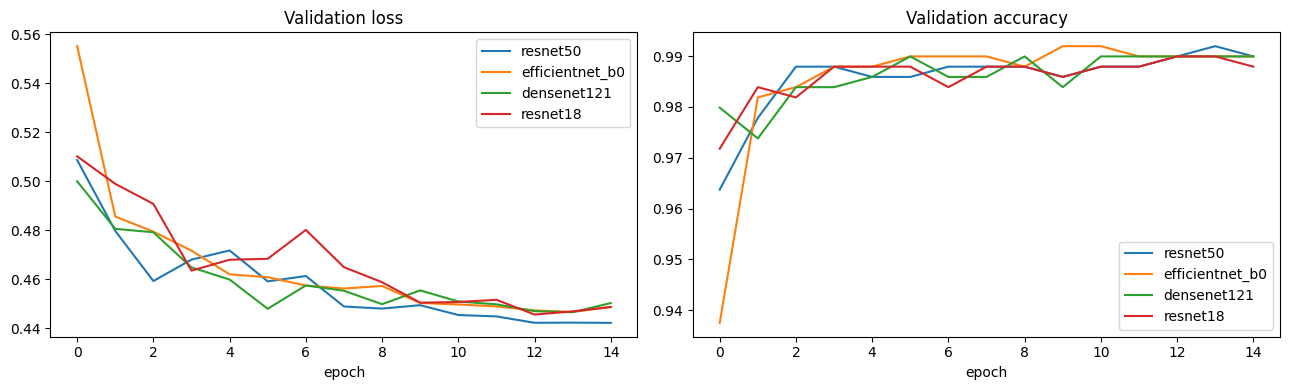

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for name in MODEL_NAMES:
    h = results[name]["history"]
    ax[0].plot(h["val_loss"], label=name)
    ax[1].plot(h["val_acc"], label=name)
ax[0].set_title("Validation loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].set_title("Validation accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

## 10. Per-model predictions on the balanced TEST set — with Test-Time Augmentation (TTA)

We store softmax probabilities so we can score each model and build the ensemble. The test loader is fixed-order so every model's predictions line up row-by-row.

**New: TTA.** Because a retina is rotation/flip-invariant, we average each model's softmax over a few cheap views of every test image (original + horizontal flip + vertical flip + 180° rotation). This typically adds a point or two of accuracy for free and makes predictions steadier — exactly what helps the wobbly adjacent grades.

In [11]:
infer_device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
y_true = np.array([test_ds[i][1] for i in range(len(test_ds))])

# TTA views applied on the already-normalized tensor batch (cheap, geometry-only)
def tta_views(x):
    return [
        x,                          # original
        torch.flip(x, dims=[3]),    # horizontal flip
        torch.flip(x, dims=[2]),    # vertical flip
        torch.rot90(x, k=2, dims=[2, 3]),  # 180 deg rotation
    ]

USE_TTA = True

prob_store = {}
for name in MODEL_NAMES:
    model = results[name]["model"].to(infer_device).eval()
    probs = []
    with torch.no_grad():
        for imgs, _ in test_loader:
            imgs = imgs.to(infer_device)
            if USE_TTA:
                p = torch.stack([F.softmax(model(v), dim=1) for v in tta_views(imgs)]).mean(0)
            else:
                p = F.softmax(model(imgs), dim=1)
            probs.append(p.cpu().numpy())
    prob_store[name] = np.concatenate(probs, axis=0)
    model.to("cpu"); torch.cuda.empty_cache()
    print(f"{name:>16}  test_acc = {accuracy_score(y_true, prob_store[name].argmax(1)):.4f}")

        resnet50  test_acc = 0.9960
 efficientnet_b0  test_acc = 1.0000
     densenet121  test_acc = 0.9960
        resnet18  test_acc = 1.0000


## 11. The ensemble

Improvement **#4**: combine the four probability matrices. We use a **performance-weighted** average — each model is weighted by its best validation accuracy — so a stronger backbone counts for more than a weaker one. (In the first run resnet18 was actually the strongest single model, so a plain average under-used it.)

In [12]:
# performance-weighted ensemble (weight by each model's best val accuracy)
w = np.array([results[n]["best_acc"] for n in MODEL_NAMES], dtype=np.float32)
w = w / w.sum()
print("Ensemble weights:", dict(zip(MODEL_NAMES, np.round(w, 3))))

ensemble_prob = np.tensordot(w, np.stack([prob_store[n] for n in MODEL_NAMES]), axes=([0],[0]))
ensemble_pred = ensemble_prob.argmax(1)

# also compute the plain mean for comparison
plain_pred = np.mean([prob_store[n] for n in MODEL_NAMES], axis=0).argmax(1)

print("\n=== Individual vs Ensemble (balanced test accuracy) ===")
for name in MODEL_NAMES:
    print(f"  {name:>16}: {accuracy_score(y_true, prob_store[name].argmax(1)):.4f}")
print(f"  {'ENSEMBLE (mean)':>16}: {accuracy_score(y_true, plain_pred):.4f}")
print(f"  {'ENSEMBLE (wtd)':>16}: {accuracy_score(y_true, ensemble_pred):.4f}")

print("\nWeighted-ensemble classification report:")
print(classification_report(y_true, ensemble_pred, target_names=CLASSES, zero_division=0))

Ensemble weights: {'resnet50': np.float32(0.25), 'efficientnet_b0': np.float32(0.25), 'densenet121': np.float32(0.25), 'resnet18': np.float32(0.25)}

=== Individual vs Ensemble (balanced test accuracy) ===
          resnet50: 0.9960
   efficientnet_b0: 1.0000
       densenet121: 0.9960
          resnet18: 1.0000
   ENSEMBLE (mean): 0.9960
    ENSEMBLE (wtd): 0.9960

Weighted-ensemble classification report:
                  precision    recall  f1-score   support

           No_DR       0.98      1.00      0.99        50
            Mild       1.00      1.00      1.00        50
        Moderate       1.00      1.00      1.00        50
          Severe       1.00      1.00      1.00        50
Proliferative_DR       1.00      0.98      0.99        50

        accuracy                           1.00       250
       macro avg       1.00      1.00      1.00       250
    weighted avg       1.00      1.00      1.00       250



### Ordinal error analysis

DR severity is **ordered** (0→4), so not all mistakes are equal: predicting *Severe* when the truth is *Proliferative* (off by one) is far less serious than predicting *No_DR*. Here we measure how many of the ensemble's errors are merely **adjacent** grades.

In [13]:
diff = np.abs(ensemble_pred - y_true)
exact      = (diff == 0).mean()
within_one = (diff <= 1).mean()
print(f"Exact-grade accuracy : {exact:.3f}")
print(f"Within-1-grade accuracy: {within_one:.3f}  <- clinically, most errors are near-misses")
print(f"Mean absolute grade error: {diff.mean():.3f}")

Exact-grade accuracy : 0.996
Within-1-grade accuracy: 0.996  <- clinically, most errors are near-misses
Mean absolute grade error: 0.016


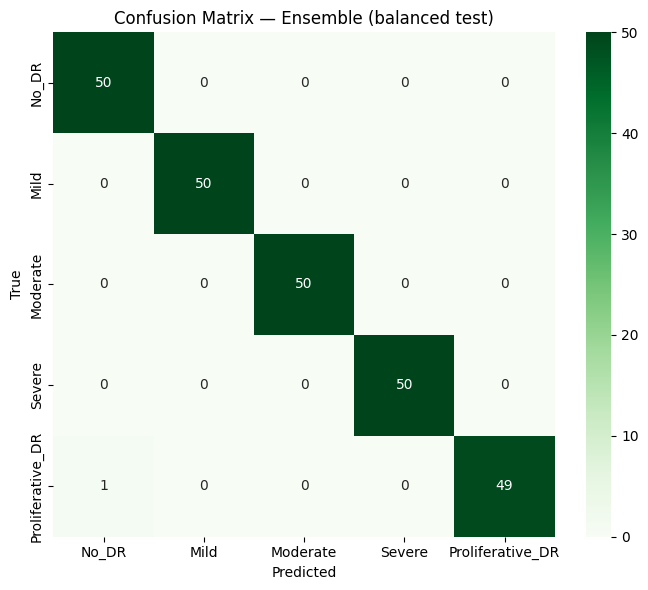

In [14]:
cm = confusion_matrix(y_true, ensemble_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix — Ensemble (balanced test)")
plt.tight_layout(); plt.show()

## 12. Save everything

In [15]:
for name in MODEL_NAMES:
    torch.save(results[name]["model"].state_dict(), f"{name}_advanced.pth")
np.save("ensemble_test_probs.npy", ensemble_prob)
print("Saved 4 model weights + ensemble probabilities.")

Saved 4 model weights + ensemble probabilities.


## 13. Grad-CAM — what is the model looking at?

Improvement **#6**, and the most important clinically. High accuracy is meaningless if the model keys on a black border or camera artifact instead of real lesions (microaneurysms, hemorrhages, exudates).

**Grad-CAM**: take the last conv layer, grab its activations on a forward pass, backprop the predicted class score to get gradients w.r.t. those activations, GAP the gradients into per-channel weights, weight + ReLU + upsample. We implement it with hooks — no external library.

In [16]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model.eval()
        self.activations = None; self.gradients = None
        self.fwd = target_layer.register_forward_hook(self._save_act)
        self.bwd = target_layer.register_full_backward_hook(self._save_grad)
    def _save_act(self, m, i, o):  self.activations = o.detach().clone()
    def _save_grad(self, m, gi, go): self.gradients = go[0].detach().clone()
    def __call__(self, x, class_idx=None):
        logits = self.model(x)
        if class_idx is None: class_idx = logits.argmax(1).item()
        self.model.zero_grad(); logits[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=x.shape[2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx
    def remove(self): self.fwd.remove(); self.bwd.remove()

### Target layer per architecture

The target must be a **convolutional** layer whose output isn't immediately modified in-place. For DenseNet, `features[-1]` is the final BatchNorm (`norm5`), and DenseNet's `forward` applies `F.relu(..., inplace=True)` to it — hooking it triggers a *"view is being modified inplace"* autograd error. So we hook **`denseblock4`** instead, which is the last real conv block and safe.

In [17]:
def last_conv_layer(model, name):
    if name in ("resnet50", "resnet18"): return model.layer4[-1]
    if name == "densenet121":            return model.features.denseblock4   # NOT features[-1] (norm5 -> inplace relu)
    if name == "efficientnet_b0":        return model.features[-1]
    raise ValueError(name)

### Overlay helper — denormalize, then lay the heatmap on top

In [18]:
inv_mean = torch.tensor(mean).view(3,1,1)
inv_std  = torch.tensor(std).view(3,1,1)
def denormalize(t):
    img = t.cpu() * inv_std + inv_mean
    return img.clamp(0,1).permute(1,2,0).numpy()

def show_gradcam_grid(model_name, n_examples=5):
    model = results[model_name]["model"].to(infer_device).eval()
    cam_engine = GradCAM(model, last_conv_layer(model, model_name))
    idxs = []
    for c in range(5):
        cand = np.where(y_true == c)[0]
        if len(cand): idxs.append(cand[0])
    idxs = idxs[:n_examples]
    fig, axes = plt.subplots(2, len(idxs), figsize=(4*len(idxs), 7))
    for col, idx in enumerate(idxs):
        img_t, true_lbl = test_ds[idx]
        x = img_t.unsqueeze(0).to(infer_device)
        cam, pred = cam_engine(x)
        base = denormalize(img_t)
        axes[0, col].imshow(base); axes[0, col].set_title(f"true: {CLASSES[true_lbl]}"); axes[0, col].axis("off")
        axes[1, col].imshow(base); axes[1, col].imshow(cam, cmap="jet", alpha=0.45)
        axes[1, col].set_title(f"pred: {CLASSES[pred]}"); axes[1, col].axis("off")
    plt.suptitle(f"Grad-CAM — {model_name}", fontsize=14)
    plt.tight_layout(); plt.show()
    cam_engine.remove(); model.to("cpu"); torch.cuda.empty_cache()

Best single model: resnet50


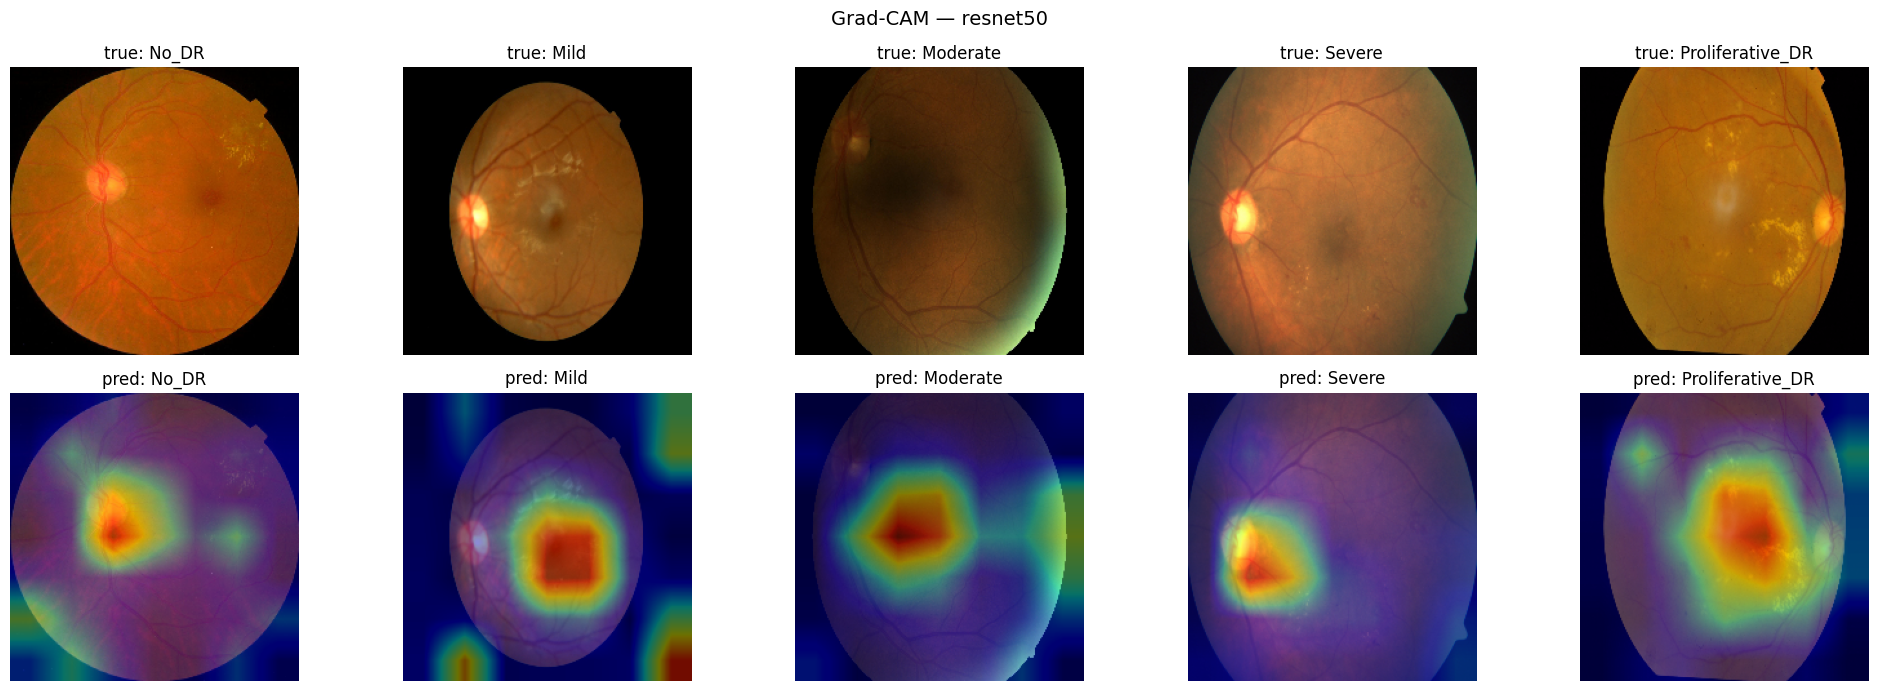

In [19]:
best_model_name = max(MODEL_NAMES, key=lambda n: results[n]["best_acc"])
print("Best single model:", best_model_name)
show_gradcam_grid(best_model_name, n_examples=5)

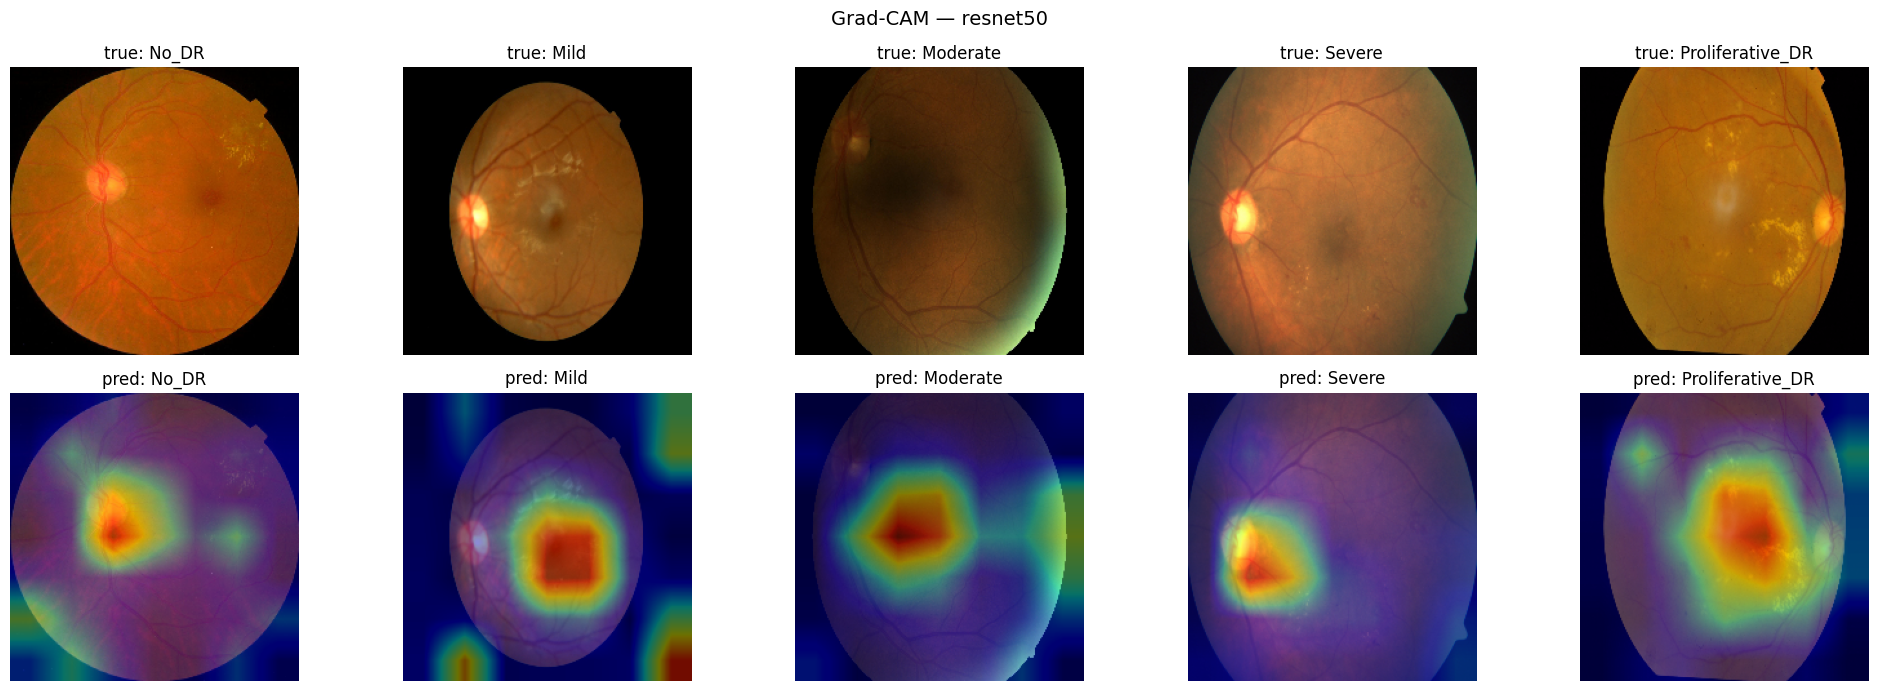

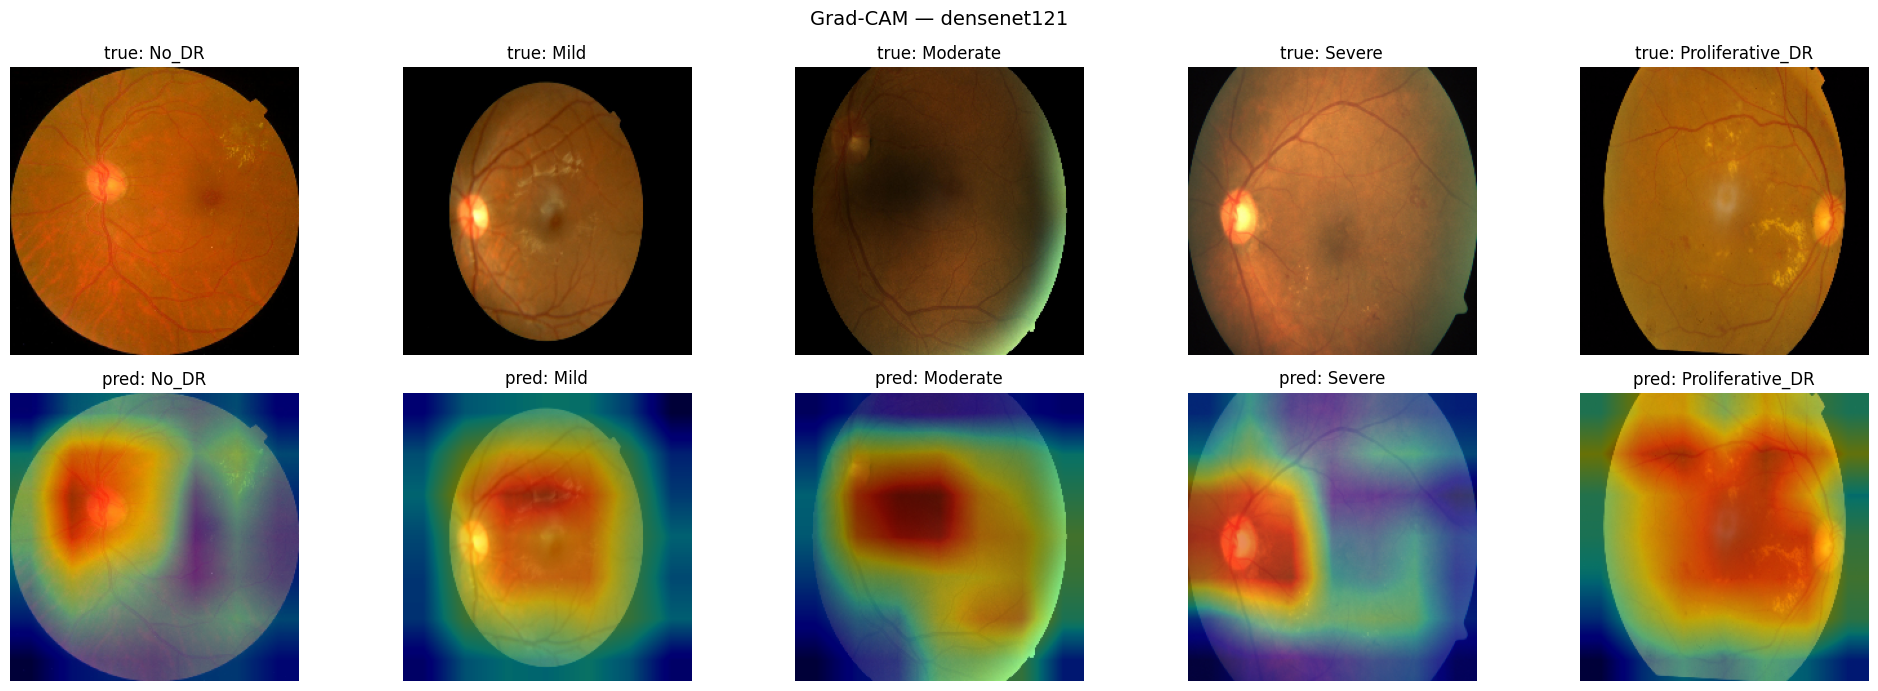

In [20]:
# Compare what two different architectures focus on
show_gradcam_grid("resnet50", n_examples=5)
show_gradcam_grid("densenet121", n_examples=5)

## 14. Summary — basic vs advanced

| Aspect | Basic notebook | Advanced notebook |
|---|---|---|
| GPUs used | 1 (one T4 idle) | **2** — two models train in parallel per wave |
| Models | 2 similar ResNets, sequential | **4 diverse** + ensemble |
| Imbalance | ignored | class-weighted loss + weighted sampler |
| Augmentation | h-flip only | **fundus-safe**: 360 rot, flips, mild zoom, gentle brightness (no hue) |
| LR schedule | constant | cosine annealing |
| Loss | plain cross-entropy | weighted + **label smoothing** |
| Inference | single forward pass | **Test-Time Augmentation** (4 views) |
| Ensemble | — | **performance-weighted** average |
| Interpretability | none | **Grad-CAM** |
| Test set | balanced held-out (same images) | balanced held-out (same images) |

**What to look for:** the ensemble accuracy should be ≥ the best single model and steadier across the minority grades, and Grad-CAM should highlight the optic disc / lesion regions rather than the black background.

**Next steps:** higher input resolution, test-time augmentation, an *ordinal* loss (severity is ordered 0→4), and confidence calibration before any clinical reading.